# Applying TDA to US house of representatives voting data
Goal: Reproduce the results from the paper "Extracting insights from the shape of complex data using topology" (https://www.nature.com/articles/srep01236)

Method: We intend to use the python package kmapper to apply the mapper algorithm to the minimal dataset, created in `TDA_practical/exploratory/data_csv_structure.ipynb`


## TEMPORARY
Copied code from Exercise sheet 4 on mapper

In [ ]:
import numpy as np
import sklearn
import kmapper as km
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KernelDensity

data_raw = pd.DataFrame.to_numpy(df_data.drop(['group'], axis=1))

scaler=MinMaxScaler()
data=scaler.fit_transform(data_raw)
data-=np.mean(data,axis=0)
data

#Initalize Mapper and DBscan as clustering method
mapper = km.KeplerMapper(verbose=2)
cluster_method=sklearn.cluster.DBSCAN(eps=0.7,min_samples=2)

#Simple gaussian kernel KDE filter 
def sklearn_density_filter(X, bandwidth):
    """
    Returns estimated density values at the sample points.
    """
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(X)

    log_density = kde.score_samples(X)   
    density = np.exp(log_density)
    return log_density

density = sklearn_density_filter(data, bandwidth=0.3)

lens = density.reshape(-1, 1)

#Create cover similar to paper
cover=km.Cover(n_cubes=4, perc_overlap=0.5)

#Create graph
graph = mapper.map(
    lens,
    data,
    clusterer=cluster_method,
    cover=cover
)

# Visualize density values
#mapper.visualize(graph, path_html="diabetes.html",color_values=density,color_function_name="KDE density")

# Visualize group colors
mapper.visualize(graph, path_html="diabetes.html",color_values=labels,color_function_name="diabetes type")

# First try on mapper implementation: 

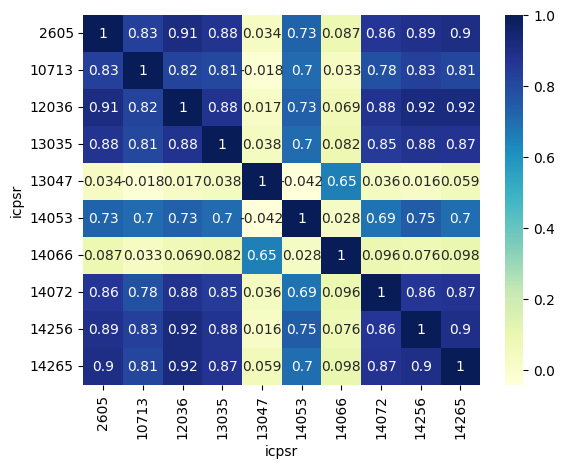

In [22]:
import pandas as pd
import numpy as np
import kmapper as km
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

df_data = pd.read_csv("../data/processed_data.csv")

vote_matrix_09 = df_data[df_data['date'] < '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)
vote_matrix_10 = df_data[df_data['date'] >= '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)

corr_09 = vote_matrix_09.T.corr()
corr_10 = vote_matrix_10.T.corr()

sns.heatmap(corr_09.iloc[:10, :10], cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()


Next we compute the distance matrix from the correlation and compute the SVD as in the paper, 

In [21]:
distance_09 = (1 - corr_09).fillna(0)
distance_10 = (1 - corr_10).fillna(0)

U_09, singular_values_09, Vt_09 = np.linalg.svd(distance_09.to_numpy())
U_10, singular_values_10, Vt_10 = np.linalg.svd(distance_10.to_numpy())

lens_09 = U_09[:, :2] * singular_values_09[:2]
lens_10 = U_10[:, :2] * singular_values_10[:2]


In [28]:
mapper = km.KeplerMapper(verbose=2)
cluster_method=sklearn.cluster.DBSCAN(eps=0.7,min_samples=2)


cover = km.Cover(
    n_cubes=120,
    perc_overlap=0.78,
)

clusterer = DBSCAN(
    metric="precomputed",
    eps=0.20,
    min_samples=2,
)

graph_09 = mapper.map(
    lens_09,
    X=distance_09.to_numpy(),
    precomputed=True,
    cover=cover,
    clusterer=clusterer,
)

graph_10 = mapper.map(
    lens_10,
    X=distance_10.to_numpy(),
    precomputed=True,
    cover=cover,
    clusterer=clusterer,
)

mapper.visualize(
    graph_09,
    path_html="house_mapper_2009.html",
    title="US House voting behavior, 2009")

mapper.visualize(
    graph_10,
    path_html="house_mapper_2010.html",
    title="US House voting behavior, 2010")


KeplerMapper(verbose=2)
Mapping on data shaped (447, 447) using lens shaped (447, 2)

Minimal points in hypercube before clustering: 2
Creating 14400 hypercubes.
Cube_0 is empty.

Cube_1 is empty.

Cube_2 is empty.

Cube_3 is empty.

Cube_4 is empty.

Cube_5 is empty.

Cube_6 is empty.

Cube_7 is empty.

Cube_8 is empty.

Cube_9 is empty.

Cube_10 is empty.

Cube_11 is empty.

Cube_12 is empty.

Cube_13 is empty.

Cube_14 is empty.

Cube_15 is empty.

Cube_16 is empty.

Cube_17 is empty.

Cube_18 is empty.

Cube_19 is empty.

Cube_20 is empty.

Cube_21 is empty.

Cube_22 is empty.

Cube_23 is empty.

Cube_24 is empty.

Cube_25 is empty.

Cube_26 is empty.

Cube_27 is empty.

Cube_28 is empty.

Cube_29 is empty.

Cube_30 is empty.

Cube_31 is empty.

Cube_32 is empty.

Cube_33 is empty.

Cube_34 is empty.

Cube_35 is empty.

Cube_36 is empty.

Cube_37 is empty.

Cube_38 is empty.

Cube_39 is empty.

Cube_40 is empty.

Cube_41 is empty.

Cube_42 is empty.

Cube_43 is empty.

Cube_44 is e

'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>US House voting behavior, 2010 | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13

In [35]:
member_info = (
    df_data[["icpsr", "party_name", "bioname"]]
    .drop_duplicates("icpsr")
    .set_index("icpsr")
)

party_color = (
    member_info["party_name"]
    .map({
        "Democrat": 0.0,
        "Republican": 1.0,
    })
    .fillna(0.5)
    .to_numpy()
)

mapper.visualize(
    graph_09,
    path_html="house_mapper_2009.html",
    title="US House voting behavior, 2009",
    color_values=party_color,
    color_function_name="Party",
    node_color_function="mean",
    colorscale=[
        [0.0, "#0000ff"],
        [0.5, "#b0b0b0"],
        [1.0, "#ff0000"],
    ],
    custom_tooltips=member_info["bioname"].to_numpy(),
)

mapper.visualize(
    graph_10,
    path_html="house_mapper_2010.html",
    title="US House voting behavior, 2010",
    color_values=party_color,
    color_function_name="Party",
    node_color_function="mean",
    colorscale=[
        [0.0, "#0000ff"],
        [0.5, "#b0b0b0"],
        [1.0, "#ff0000"],
    ],
    custom_tooltips=member_info["bioname"].to_numpy(),
)

Wrote visualization to: house_mapper_2009.html
Wrote visualization to: house_mapper_2010.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>US House voting behavior, 2010 | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13